# MÔ HÌNH SỐ 3: STATE SPACE MODEL + KALMAN FILTER
## Dự báo tỷ giá USD/VND

Notebook này triển khai **mô hình không gian trạng thái tuyến tính Gaussian** cho chuỗi **log-price** của tỷ giá USD/VND, sau đó dùng **Kalman Filter** để dự báo và **Kalman Smoother** để ước lượng các trạng thái ẩn.

Cơ sở lý thuyết bám theo **Shumway & Stoffer, *Time Series Analysis and Its Applications: With R Examples*, 4th ed., Chapter 6**, đặc biệt các phần:

- 6.1 Linear Gaussian Model
- 6.2 Filtering, Smoothing, and Forecasting
- 6.3 Maximum Likelihood Estimation
- 6.5 Structural Models: Signal Extraction and Forecasting

Với dạng **Local Linear Trend**, ta mô hình hóa:

\[
y_t = \mu_t + \varepsilon_t,
\]

\[
\mu_t = \mu_{t-1} + \beta_{t-1} + \eta_t,
\]

\[
\beta_t = \beta_{t-1} + \zeta_t,
\]

trong đó \(y_t=\log(P_t)\), \(\mu_t\) là mức giá ẩn, \(\beta_t\) là xu hướng ẩn. Kalman Filter cập nhật trạng thái khi có quan sát mới; Kalman Smoother dùng toàn bộ mẫu để ước lượng trạng thái ẩn.

### Thiết kế đánh giá

- **Train 2016–2024:** ước lượng tham số.
- **Validation 2025:** chọn cấu trúc State Space.
- **Test 2026:** đánh giá cuối cùng, tuyệt đối không dùng để chọn mô hình.
- Tiêu chí chính: **MAE, RMSE, MAPE, sMAPE, MASE, Directional Accuracy, Relative RMSE so với Naive**.
- Đánh giá khoảng dự báo: **95% Prediction Interval Coverage** và **Average Interval Width**.
- Chẩn đoán phần dư chuẩn hóa: **Ljung-Box, Jarque-Bera, ARCH-LM**.

Dự báo chính dùng **rolling one-step-ahead**: tại mỗi phiên, mô hình dự báo 1 bước trước rồi Kalman Filter cập nhật trạng thái bằng quan sát thực tế. Đây là thiết kế phù hợp để đánh giá dự báo ngắn hạn hàng ngày.

## 0. Thư viện cần thiết

Nếu máy chưa có thư viện, chạy một lần trong Terminal:

```bash
pip install pandas numpy matplotlib scipy statsmodels
```

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from scipy.stats import jarque_bera, norm, probplot

from statsmodels.tsa.statespace.structural import UnobservedComponents
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.graphics.tsaplots import plot_acf

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

## 1. Thiết lập đường dẫn

Notebook được thiết kế theo đúng cấu trúc thư mục hiện tại của nhóm:

```text
Chuyên đề 2/
├── code/
├── data/processed/
├── figures/
└── results/
```

In [2]:
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "code":
    BASE_DIR = CURRENT_DIR.parent
else:
    BASE_DIR = CURRENT_DIR

DATA_DIR = BASE_DIR / "data" / "processed"
FIGURE_DIR = BASE_DIR / "figures" / "model_3_state_space"
RESULT_DIR = BASE_DIR / "results" / "model_3_state_space"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

print("BASE_DIR   :", BASE_DIR)
print("DATA_DIR   :", DATA_DIR)
print("FIGURE_DIR :", FIGURE_DIR)
print("RESULT_DIR :", RESULT_DIR)

BASE_DIR   : /mnt/data/USD_VND_notebooks
DATA_DIR   : /mnt/data/USD_VND_notebooks/data/processed
FIGURE_DIR : /mnt/data/USD_VND_notebooks/figures/model_3_state_space
RESULT_DIR : /mnt/data/USD_VND_notebooks/results/model_3_state_space


## 2. Đọc Train / Validation / Test

Mô hình State Space sử dụng **log_price** làm biến quan sát chính. Tỷ giá `Close` được giữ lại để đánh giá dự báo trên đơn vị gốc VND cho 1 USD.

In [3]:
required_files = {
    "train": DATA_DIR / "price_train.csv",
    "validation": DATA_DIR / "price_validation.csv",
    "test": DATA_DIR / "price_test.csv",
}

for name, path in required_files.items():
    if not path.exists():
        raise FileNotFoundError(f"Không tìm thấy file {name}: {path}")

price_train = pd.read_csv(required_files["train"], parse_dates=["Date"])
price_val = pd.read_csv(required_files["validation"], parse_dates=["Date"])
price_test = pd.read_csv(required_files["test"], parse_dates=["Date"])

for df in (price_train, price_val, price_test):
    df.sort_values("Date", inplace=True)
    df.reset_index(drop=True, inplace=True)
    if "log_price" not in df.columns:
        df["log_price"] = np.log(df["Close"])

print("Train      :", price_train.shape, price_train["Date"].min(), "->", price_train["Date"].max())
print("Validation :", price_val.shape, price_val["Date"].min(), "->", price_val["Date"].max())
print("Test       :", price_test.shape, price_test["Date"].min(), "->", price_test["Date"].max())

Train      : (2347, 6) 2016-01-04 00:00:00 -> 2024-12-31 00:00:00
Validation : (262, 6) 2025-01-01 00:00:00 -> 2025-12-31 00:00:00
Test       : (175, 6) 2026-01-01 00:00:00 -> 2026-08-31 00:00:00


## 3. Kiểm tra dữ liệu đầu vào lần cuối

Các điều kiện bắt buộc:

- `Date` không trùng.
- `Close > 0` để lấy logarithm.
- `Close` và `log_price` không missing.
- Ba tập dữ liệu phải giữ đúng thứ tự thời gian.

In [4]:
def audit_split(df, name):
    out = {
        "Split": name,
        "N": len(df),
        "Start": df["Date"].min(),
        "End": df["Date"].max(),
        "Missing_Close": int(df["Close"].isna().sum()),
        "Missing_LogPrice": int(df["log_price"].isna().sum()),
        "Duplicate_Date": int(df["Date"].duplicated().sum()),
        "Nonpositive_Close": int((df["Close"] <= 0).sum()),
    }
    return out

audit_table = pd.DataFrame([
    audit_split(price_train, "Train"),
    audit_split(price_val, "Validation"),
    audit_split(price_test, "Test"),
])

print(audit_table.to_string(index=False))

audit_table.to_csv(RESULT_DIR / "01_data_audit.csv", index=False)

if (
    audit_table[["Missing_Close", "Missing_LogPrice", "Duplicate_Date", "Nonpositive_Close"]]
    .to_numpy()
    .sum() > 0
):
    raise ValueError("Dữ liệu còn lỗi. Hãy xử lý trước khi chạy State Space Model.")

     Split    N      Start        End  Missing_Close  Missing_LogPrice  Duplicate_Date  Nonpositive_Close
     Train 2347 2016-01-04 2024-12-31              0                 0               0                  0
Validation  262 2025-01-01 2025-12-31              0                 0               0                  0
      Test  175 2026-01-01 2026-08-31              0                 0               0                  0


## 4. Trực quan hóa phân chia dữ liệu

Biểu đồ này dùng để xác nhận ranh giới Train, Validation và Test trước khi bắt đầu mô hình hóa.

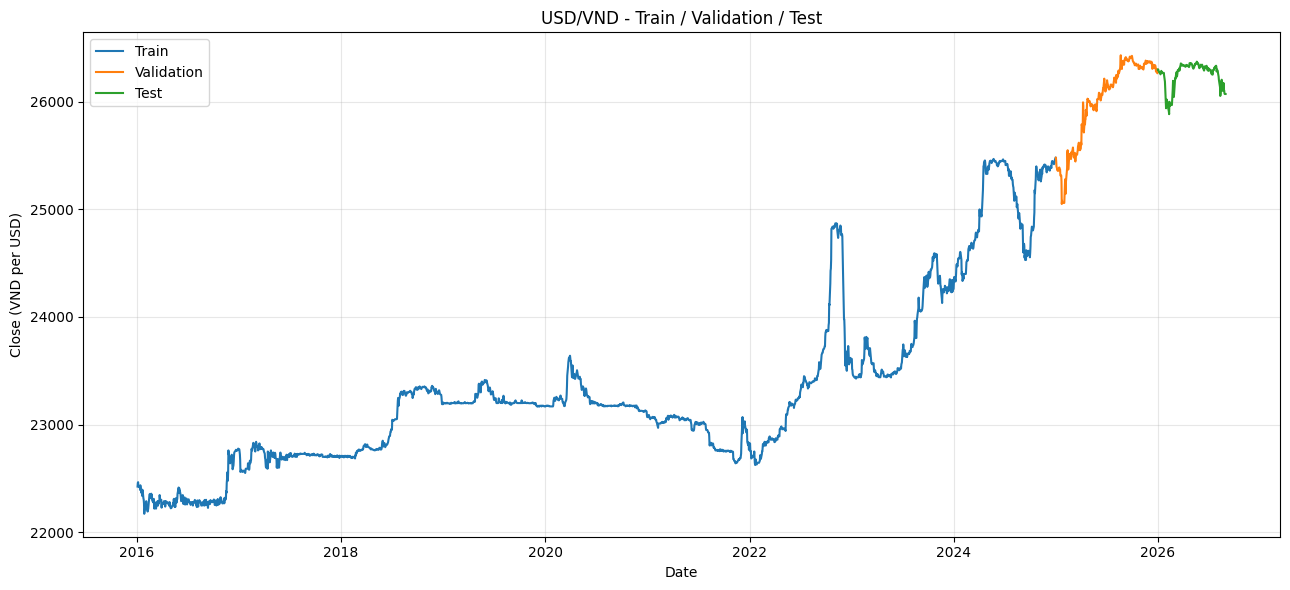

In [5]:
plt.figure(figsize=(13, 6))
plt.plot(price_train["Date"], price_train["Close"], label="Train")
plt.plot(price_val["Date"], price_val["Close"], label="Validation")
plt.plot(price_test["Date"], price_test["Close"], label="Test")
plt.title("USD/VND - Train / Validation / Test")
plt.xlabel("Date")
plt.ylabel("Close (VND per USD)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "01_data_split.png", dpi=300)
plt.show()

## 5. Hàm đánh giá dự báo

Các tiêu chí được dùng:

- **MAE**: sai số tuyệt đối trung bình. Càng thấp càng tốt.
- **RMSE**: phạt mạnh các sai số lớn. Càng thấp càng tốt.
- **MAPE**: sai số phần trăm tuyệt đối trung bình. Càng thấp càng tốt.
- **sMAPE**: phiên bản đối xứng của MAPE. Càng thấp càng tốt.
- **MASE**: so MAE của mô hình với sai số dự báo Naive một bước trong mẫu huấn luyện. **MASE < 1** nghĩa là tốt hơn Naive theo MAE.
- **Directional Accuracy (DA)**: tỷ lệ dự báo đúng hướng tăng/giảm.
- **Relative RMSE vs Naive**: RMSE mô hình / RMSE Naive. **< 1** nghĩa là tốt hơn Naive theo RMSE.
- **PI Coverage 95%**: tỷ lệ giá thật nằm trong khoảng dự báo 95%. Lý tưởng gần 95%, nhưng phải xem cùng độ rộng khoảng.
- **Average PI Width**: độ rộng trung bình của khoảng dự báo. Càng hẹp càng tốt nếu vẫn duy trì coverage hợp lý.

Benchmark Naive:

\[
\hat P_t^{Naive}=P_{t-1}.
\]

In [6]:
def compute_forecast_metrics(actual, predicted, previous_actual, mase_scale, lower=None, upper=None):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    previous_actual = np.asarray(previous_actual, dtype=float)

    error = actual - predicted
    mae = np.mean(np.abs(error))
    rmse = np.sqrt(np.mean(error ** 2))
    mape = np.mean(np.abs(error / actual)) * 100
    smape = np.mean(2 * np.abs(error) / (np.abs(actual) + np.abs(predicted))) * 100
    mase = mae / mase_scale if mase_scale > 0 else np.nan

    actual_direction = np.sign(actual - previous_actual)
    predicted_direction = np.sign(predicted - previous_actual)
    directional_accuracy = np.mean(actual_direction == predicted_direction) * 100

    naive_pred = previous_actual
    naive_rmse = np.sqrt(np.mean((actual - naive_pred) ** 2))
    relative_rmse = rmse / naive_rmse if naive_rmse > 0 else np.nan

    metrics = {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE_percent": mape,
        "sMAPE_percent": smape,
        "MASE": mase,
        "Directional_Accuracy_percent": directional_accuracy,
        "Naive_RMSE": naive_rmse,
        "Relative_RMSE_vs_Naive": relative_rmse,
    }

    if lower is not None and upper is not None:
        lower = np.asarray(lower, dtype=float)
        upper = np.asarray(upper, dtype=float)
        coverage = np.mean((actual >= lower) & (actual <= upper)) * 100
        avg_width = np.mean(upper - lower)
        metrics["PI95_Coverage_percent"] = coverage
        metrics["Average_PI95_Width"] = avg_width

    return metrics

## 6. Hàm fit State Space và rolling one-step forecast

### Back-transform từ log-price về price

Nếu forecast của log-price có phân phối gần Gaussian với mean \(m\) và variance \(v\), thì:

- Median trên thang giá: `exp(m)`
- Mean có bias correction: `exp(m + 0.5*v)`

Notebook dùng **bias-corrected mean** làm point forecast chính, đồng thời lưu cả median để đối chiếu.

Ở rolling one-step forecast, **tham số mô hình không được fit lại bằng Validation/Test**. Kalman Filter chỉ cập nhật trạng thái sau khi quan sát mới xuất hiện. Như vậy không dùng dữ liệu tương lai để ước lượng tham số.

In [7]:
def fit_state_space(log_series, specification):
    y = pd.Series(log_series, dtype=float).reset_index(drop=True)

    model = UnobservedComponents(
        y,
        **specification
    )

    result = model.fit(
        method="lbfgs",
        disp=False,
        maxiter=2000
    )

    return result


def rolling_one_step_forecast(fitted_result, eval_df, alpha=0.05):
    current_result = fitted_result
    records = []

    for _, row in eval_df.iterrows():
        fc = current_result.get_forecast(steps=1)

        mean_log = float(fc.predicted_mean.iloc[0])
        var_log = float(fc.var_pred_mean.iloc[0])
        var_log = max(var_log, 0.0)

        ci_log = fc.conf_int(alpha=alpha).iloc[0]
        lower_log = float(ci_log.iloc[0])
        upper_log = float(ci_log.iloc[1])

        pred_price_median = np.exp(mean_log)
        pred_price_mean = np.exp(mean_log + 0.5 * var_log)
        lower_price = np.exp(lower_log)
        upper_price = np.exp(upper_log)

        records.append({
            "Date": row["Date"],
            "Actual_Close": float(row["Close"]),
            "Actual_LogPrice": float(row["log_price"]),
            "Predicted_LogPrice": mean_log,
            "Forecast_LogVariance": var_log,
            "Predicted_Price_Median": pred_price_median,
            "Predicted_Price": pred_price_mean,
            "Lower_95": lower_price,
            "Upper_95": upper_price,
        })

        # Quan sát thực tế chỉ được dùng SAU khi forecast phiên hiện tại đã tạo xong.
        # refit=False: không ước lượng lại tham số, chỉ cập nhật Kalman state.
        current_result = current_result.append(
            [float(row["log_price"])],
            refit=False
        )

    return pd.DataFrame(records)

## 7. Các cấu trúc State Space ứng viên

Ta không mặc định một cấu trúc duy nhất. Ba structural models được so sánh trên Validation:

1. **Local Level**: mức ẩn biến động theo thời gian.
2. **Local Linear Trend**: mức và slope/trend đều có thể biến động.
3. **Smooth Trend**: trend biến động trơn hơn.

Không thêm seasonal component vì phần EDA trước đó chưa thiết lập một seasonality cố định đủ rõ cho tỷ giá USD/VND theo ngày.

**Nguyên tắc chọn:** ưu tiên **RMSE Validation thấp**, dùng MAE để hỗ trợ; AIC/BIC chỉ dùng như thông tin in-sample, không thay thế đánh giá ngoài mẫu.

In [8]:
MODEL_SPECS = {
    "Local Level": {
        "level": "local level"
    },
    "Local Linear Trend": {
        "level": "local linear trend"
    },
    "Smooth Trend": {
        "level": "smooth trend"
    },
}

candidate_fit_results = {}
candidate_predictions = {}
candidate_metrics_rows = []

train_mase_scale = price_train["Close"].diff().abs().dropna().mean()
val_previous_actual = np.r_[price_train["Close"].iloc[-1], price_val["Close"].to_numpy()[:-1]]

for model_name, spec in MODEL_SPECS.items():
    print(f"\nĐang fit: {model_name}")

    result = fit_state_space(
        price_train["log_price"],
        spec
    )

    pred_val = rolling_one_step_forecast(
        result,
        price_val,
        alpha=0.05
    )

    metrics = compute_forecast_metrics(
        actual=pred_val["Actual_Close"],
        predicted=pred_val["Predicted_Price"],
        previous_actual=val_previous_actual,
        mase_scale=train_mase_scale,
        lower=pred_val["Lower_95"],
        upper=pred_val["Upper_95"]
    )

    metrics.update({
        "Model": model_name,
        "AIC_Train": result.aic,
        "BIC_Train": result.bic,
        "LogLikelihood_Train": result.llf,
        "Converged": bool(result.mle_retvals.get("converged", True)),
    })

    candidate_fit_results[model_name] = result
    candidate_predictions[model_name] = pred_val
    candidate_metrics_rows.append(metrics)

candidate_metrics = pd.DataFrame(candidate_metrics_rows)

# Sắp xếp theo hiệu năng ngoài mẫu, không theo AIC/BIC.
candidate_metrics = candidate_metrics.sort_values(
    ["RMSE", "MAE"],
    ascending=True
).reset_index(drop=True)

print("\nKẾT QUẢ CÁC CẤU TRÚC STATE SPACE TRÊN VALIDATION")
print(candidate_metrics.to_string(index=False))

candidate_metrics.to_csv(
    RESULT_DIR / "02_candidate_validation_metrics.csv",
    index=False
)

best_model_name = candidate_metrics.loc[0, "Model"]
best_spec = MODEL_SPECS[best_model_name]

print("\nCấu trúc được chọn bằng Validation:", best_model_name)


Đang fit: Local Level



Đang fit: Local Linear Trend



Đang fit: Smooth Trend



KẾT QUẢ CÁC CẤU TRÚC STATE SPACE TRÊN VALIDATION
      MAE      RMSE  MAPE_percent  sMAPE_percent     MASE  Directional_Accuracy_percent  Naive_RMSE  Relative_RMSE_vs_Naive  PI95_Coverage_percent  Average_PI95_Width              Model      AIC_Train      BIC_Train  LogLikelihood_Train  Converged
25.188269 43.251178      0.097468       0.097497 1.439961                     47.328244   43.252829                0.999962              92.366412          136.199672        Local Level -24,371.961689 -24,360.440755        12,187.980845       True
26.142062 43.945056      0.101183       0.101193 1.494487                     49.618321   43.252829                1.016004              92.366412          137.098476 Local Linear Trend -24,360.665820 -24,343.385697        12,183.332910       True
31.396793 49.450994      0.121575       0.121552 1.794889                     39.312977   43.252829                1.143301              91.984733          149.607069       Smooth Trend -23,956.966638 -23,9

## 8. Đồ thị so sánh ứng viên trên Validation

Đây là các đồ thị **chọn cấu trúc**, chỉ dùng dữ liệu Validation. Test chưa được sử dụng.

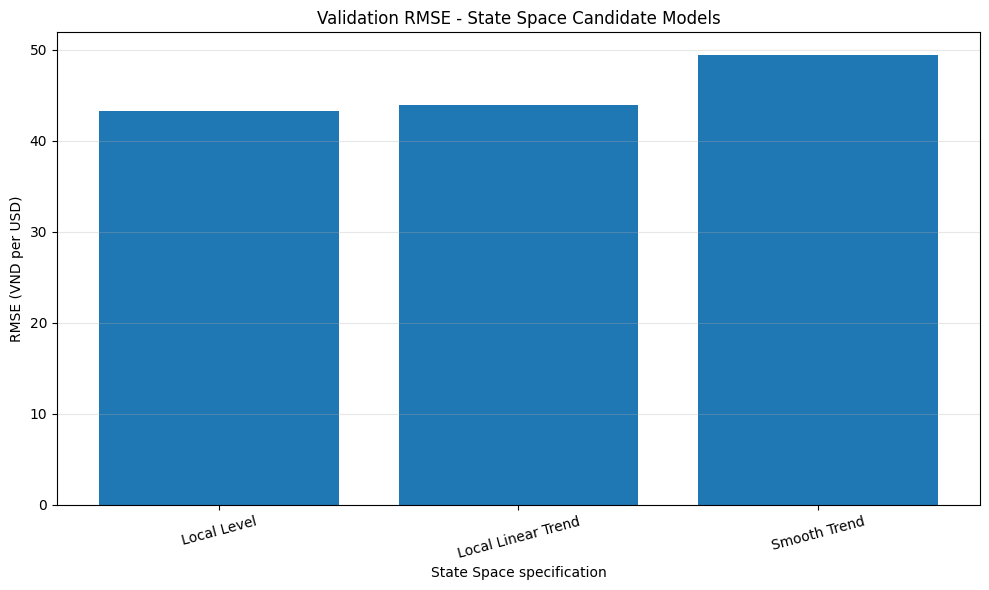

In [9]:
plt.figure(figsize=(10, 6))
order = candidate_metrics.sort_values("RMSE", ascending=True)
plt.bar(order["Model"], order["RMSE"])
plt.title("Validation RMSE - State Space Candidate Models")
plt.xlabel("State Space specification")
plt.ylabel("RMSE (VND per USD)")
plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "02_validation_rmse_candidates.png", dpi=300)
plt.show()

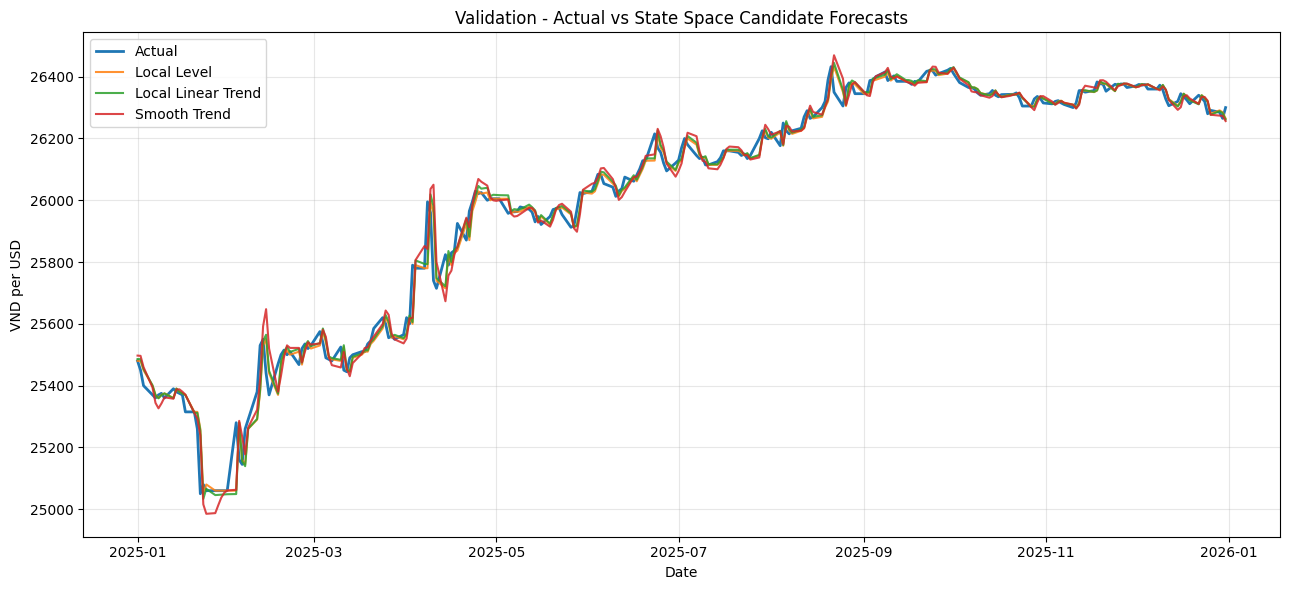

In [10]:
plt.figure(figsize=(13, 6))
plt.plot(price_val["Date"], price_val["Close"], label="Actual", linewidth=2)

for model_name in candidate_metrics["Model"]:
    pred = candidate_predictions[model_name]
    plt.plot(pred["Date"], pred["Predicted_Price"], label=model_name, alpha=0.85)

plt.title("Validation - Actual vs State Space Candidate Forecasts")
plt.xlabel("Date")
plt.ylabel("VND per USD")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "03_validation_candidate_forecasts.png", dpi=300)
plt.show()

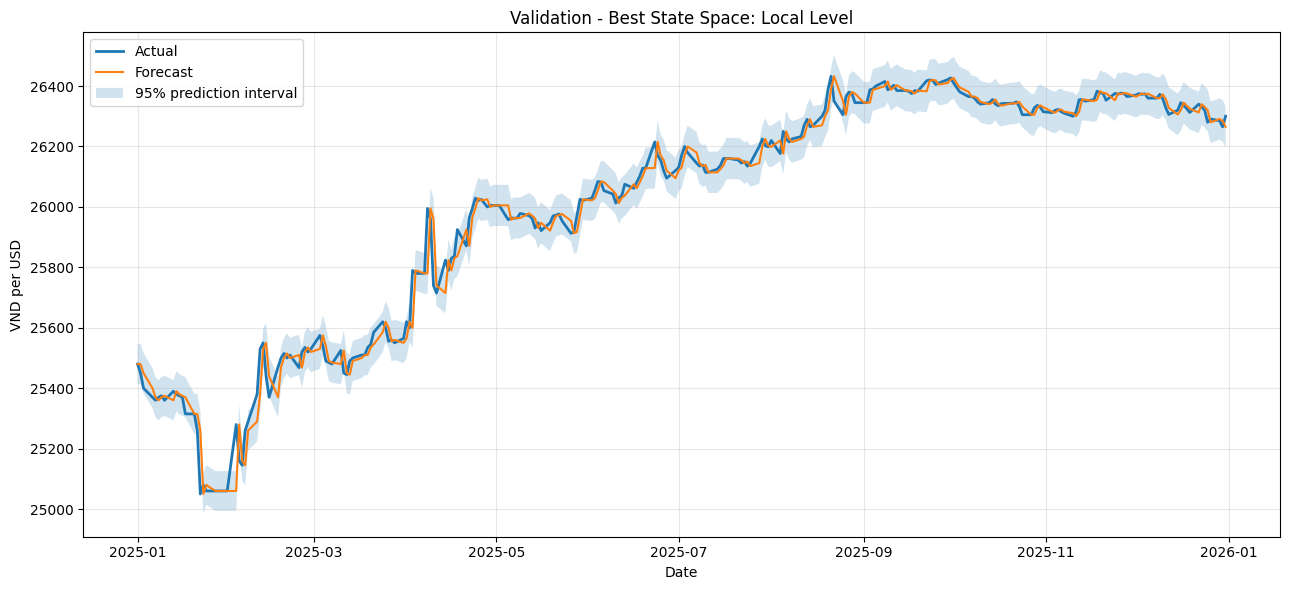

In [11]:
best_val_pred = candidate_predictions[best_model_name]

plt.figure(figsize=(13, 6))
plt.plot(best_val_pred["Date"], best_val_pred["Actual_Close"], label="Actual", linewidth=2)
plt.plot(best_val_pred["Date"], best_val_pred["Predicted_Price"], label="Forecast", linewidth=1.5)
plt.fill_between(
    best_val_pred["Date"],
    best_val_pred["Lower_95"],
    best_val_pred["Upper_95"],
    alpha=0.20,
    label="95% prediction interval"
)
plt.title(f"Validation - Best State Space: {best_model_name}")
plt.xlabel("Date")
plt.ylabel("VND per USD")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "04_validation_best_model.png", dpi=300)
plt.show()

## 9. Refit mô hình được chọn trên Train + Validation

Sau khi cấu trúc được chọn hoàn toàn bằng Validation, ta ghép:

- Train 2016–2024
- Validation 2025

để ước lượng bộ tham số cuối cùng. **Test 2026 vẫn chưa tham gia fit.**

In [12]:
price_train_val = pd.concat(
    [price_train, price_val],
    ignore_index=True
).sort_values("Date").reset_index(drop=True)

final_result = fit_state_space(
    price_train_val["log_price"],
    best_spec
)

print(final_result.summary())
print("\nConverged:", final_result.mle_retvals.get("converged", True))

with open(RESULT_DIR / "03_final_model_summary.txt", "w", encoding="utf-8") as f:
    f.write(final_result.summary().as_text())

param_names = list(final_result.params.index)
param_table = pd.DataFrame({
    "Parameter": param_names,
    "Estimate": final_result.params.to_numpy(),
    "Std_Error": final_result.bse.to_numpy(),
    "z_value": final_result.tvalues.to_numpy(),
    "p_value": final_result.pvalues.to_numpy(),
})

print("\nBẢNG THAM SỐ")
print(param_table.to_string(index=False))

param_table.to_csv(
    RESULT_DIR / "04_final_model_parameters.csv",
    index=False
)

# Lưu object statsmodels để có thể nạp lại sau này.
final_result.save(RESULT_DIR / "state_space_final_model.pkl")

                        Unobserved Components Results                         
Dep. Variable:              log_price   No. Observations:                 2609
Model:                    local level   Log Likelihood               13475.293
Date:                Tue, 06 Oct 2026   AIC                         -26946.585
Time:                        17:31:40   BIC                         -26934.853
Sample:                             0   HQIC                        -26942.335
                               - 2609                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
sigma2.irregular  6.764e-12   2.13e-08      0.000      1.000   -4.18e-08    4.18e-08
sigma2.level      1.893e-06   3.61e-08     52.487      0.000    1.82e-06    1.96e-06
Ljung-Box (L1) (Q):         

## 10. Đánh giá cuối trên Test bằng rolling one-step-ahead

Đây là kết quả chính dùng để so sánh với 4 mô hình còn lại.

Quy trình mỗi phiên Test:

1. Dự báo giá phiên kế tiếp.
2. Ghi lại forecast và prediction interval.
3. Sau đó mới đưa giá thật của phiên đó vào Kalman Filter để cập nhật state.
4. Không refit tham số trên Test.

In [13]:
test_predictions = rolling_one_step_forecast(
    final_result,
    price_test,
    alpha=0.05
)

test_previous_actual = np.r_[
    price_train_val["Close"].iloc[-1],
    price_test["Close"].to_numpy()[:-1]
]

test_mase_scale = price_train_val["Close"].diff().abs().dropna().mean()

test_metrics = compute_forecast_metrics(
    actual=test_predictions["Actual_Close"],
    predicted=test_predictions["Predicted_Price"],
    previous_actual=test_previous_actual,
    mase_scale=test_mase_scale,
    lower=test_predictions["Lower_95"],
    upper=test_predictions["Upper_95"]
)

test_metrics_table = pd.DataFrame([
    {"Model": f"State Space - {best_model_name}", **test_metrics}
])

print("\nKẾT QUẢ TEST - ROLLING ONE-STEP")
print(test_metrics_table.to_string(index=False))

test_metrics_table.to_csv(
    RESULT_DIR / "05_test_metrics_state_space.csv",
    index=False
)

test_predictions["Error"] = (
    test_predictions["Actual_Close"] - test_predictions["Predicted_Price"]
)
test_predictions["Absolute_Error"] = test_predictions["Error"].abs()
test_predictions["Squared_Error"] = test_predictions["Error"] ** 2

test_predictions.to_csv(
    RESULT_DIR / "06_test_predictions_state_space.csv",
    index=False
)


KẾT QUẢ TEST - ROLLING ONE-STEP
                    Model       MAE      RMSE  MAPE_percent  sMAPE_percent     MASE  Directional_Accuracy_percent  Naive_RMSE  Relative_RMSE_vs_Naive  PI95_Coverage_percent  Average_PI95_Width
State Space - Local Level 18.567821 30.054512      0.070918       0.070926 1.016560                     40.000000   30.053405                1.000037              94.857143          141.569833


## 11. So sánh với Naive benchmark

Naive một bước dùng giá phiên trước làm forecast phiên hiện tại. Nếu State Space không vượt được Naive thì phải báo cáo trung thực; không được điều chỉnh mô hình dựa trên Test để làm kết quả đẹp hơn.

In [14]:
naive_test_pred = test_previous_actual.copy()

naive_metrics = compute_forecast_metrics(
    actual=test_predictions["Actual_Close"],
    predicted=naive_test_pred,
    previous_actual=test_previous_actual,
    mase_scale=test_mase_scale
)

comparison_table = pd.DataFrame([
    {
        "Model": f"State Space - {best_model_name}",
        "MAE": test_metrics["MAE"],
        "RMSE": test_metrics["RMSE"],
        "MAPE_percent": test_metrics["MAPE_percent"],
        "sMAPE_percent": test_metrics["sMAPE_percent"],
        "MASE": test_metrics["MASE"],
        "Directional_Accuracy_percent": test_metrics["Directional_Accuracy_percent"],
    },
    {
        "Model": "Naive P(t-1)",
        "MAE": naive_metrics["MAE"],
        "RMSE": naive_metrics["RMSE"],
        "MAPE_percent": naive_metrics["MAPE_percent"],
        "sMAPE_percent": naive_metrics["sMAPE_percent"],
        "MASE": naive_metrics["MASE"],
        "Directional_Accuracy_percent": naive_metrics["Directional_Accuracy_percent"],
    }
])

print(comparison_table.to_string(index=False))

comparison_table.to_csv(
    RESULT_DIR / "07_state_space_vs_naive.csv",
    index=False
)

                    Model       MAE      RMSE  MAPE_percent  sMAPE_percent     MASE  Directional_Accuracy_percent
State Space - Local Level 18.567821 30.054512      0.070918       0.070926 1.016560                     40.000000
             Naive P(t-1) 18.562857 30.053405      0.070899       0.070908 1.016289                     10.285714


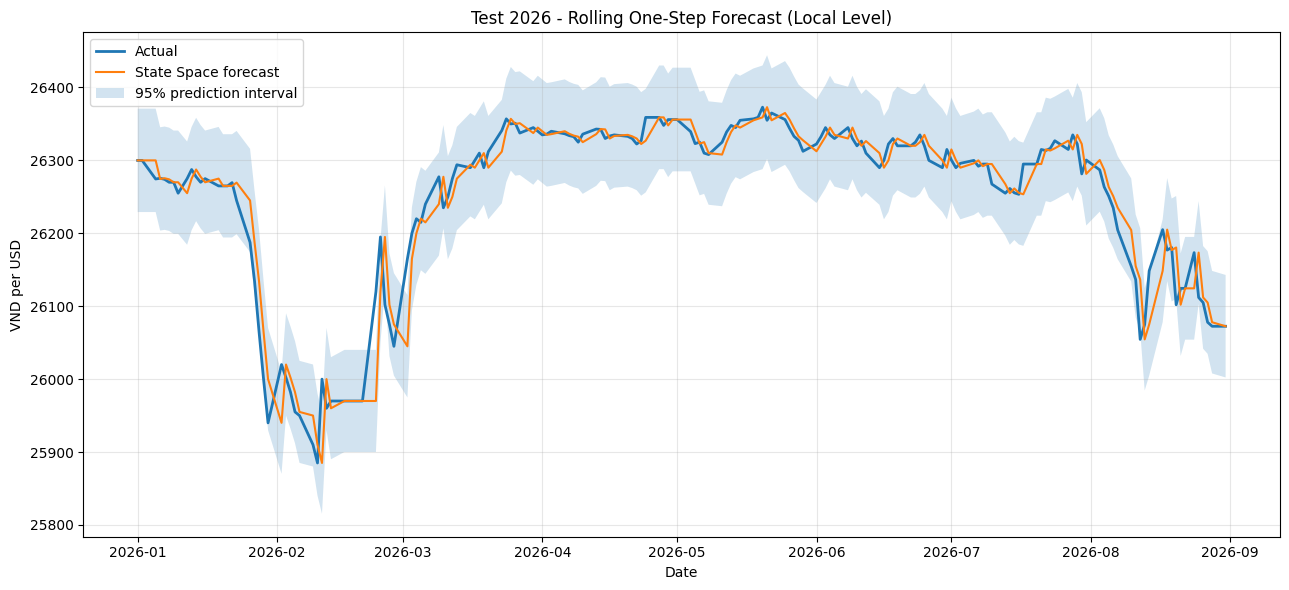

In [15]:
plt.figure(figsize=(13, 6))
plt.plot(test_predictions["Date"], test_predictions["Actual_Close"], label="Actual", linewidth=2)
plt.plot(test_predictions["Date"], test_predictions["Predicted_Price"], label="State Space forecast", linewidth=1.5)
plt.fill_between(
    test_predictions["Date"],
    test_predictions["Lower_95"],
    test_predictions["Upper_95"],
    alpha=0.20,
    label="95% prediction interval"
)
plt.title(f"Test 2026 - Rolling One-Step Forecast ({best_model_name})")
plt.xlabel("Date")
plt.ylabel("VND per USD")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "05_test_actual_vs_forecast.png", dpi=300)
plt.show()

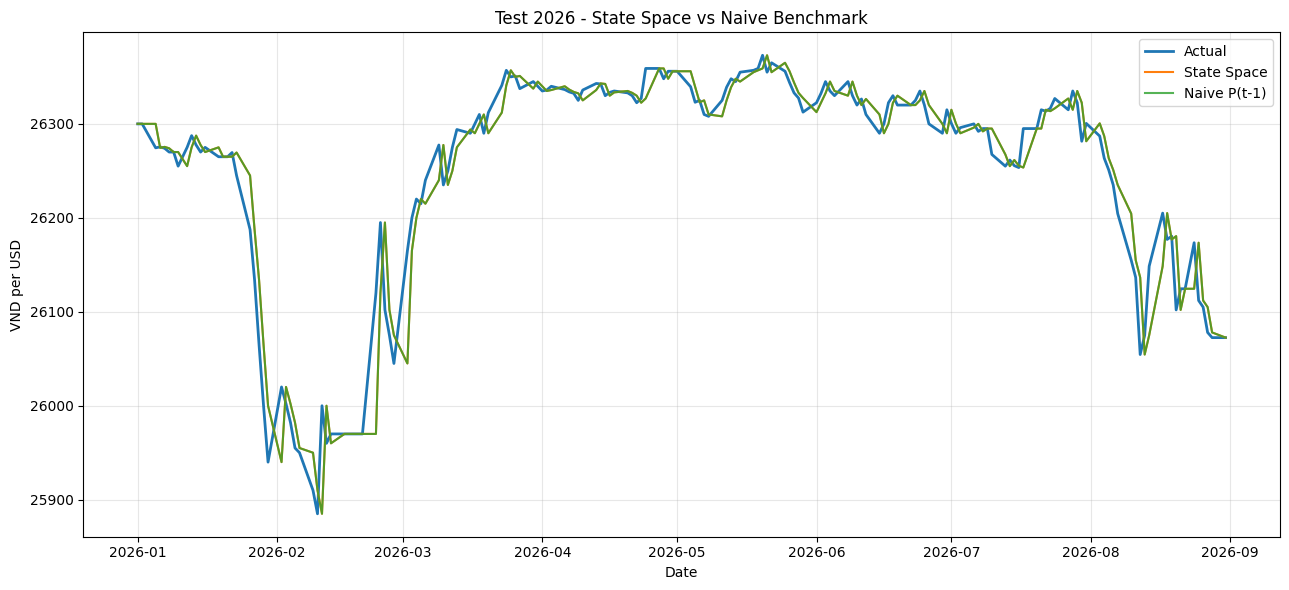

In [16]:
plt.figure(figsize=(13, 6))
plt.plot(test_predictions["Date"], test_predictions["Actual_Close"], label="Actual", linewidth=2)
plt.plot(test_predictions["Date"], test_predictions["Predicted_Price"], label="State Space")
plt.plot(test_predictions["Date"], naive_test_pred, label="Naive P(t-1)", alpha=0.8)
plt.title("Test 2026 - State Space vs Naive Benchmark")
plt.xlabel("Date")
plt.ylabel("VND per USD")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "06_test_state_space_vs_naive.png", dpi=300)
plt.show()

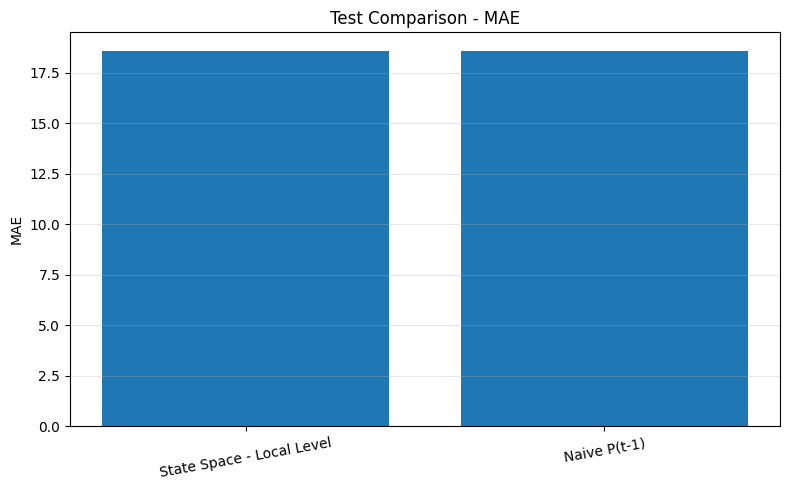

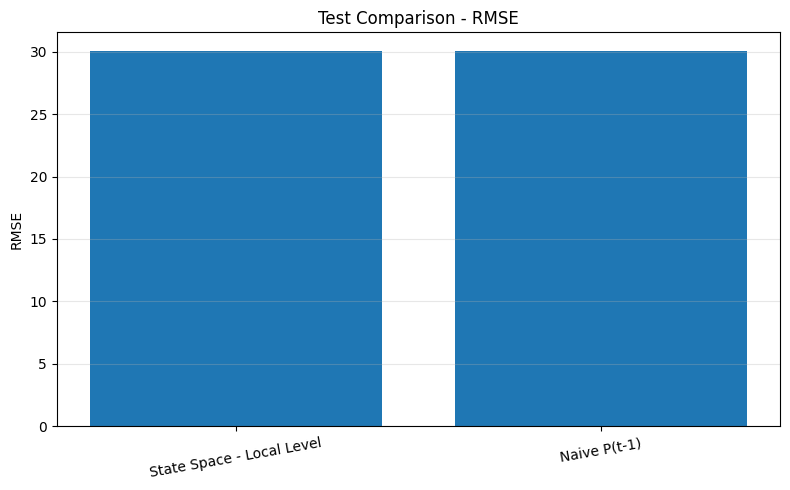

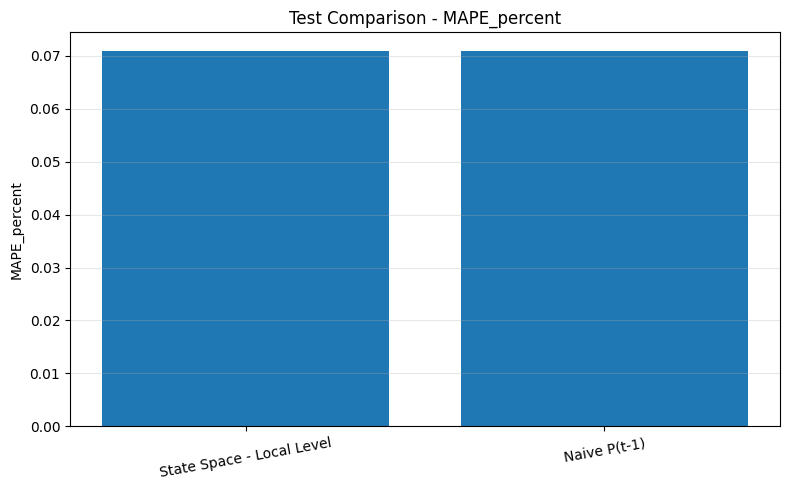

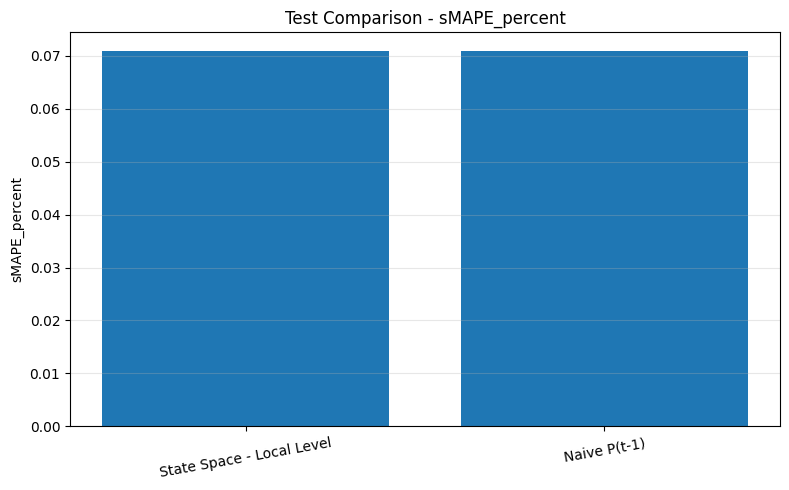

In [17]:
metric_names = ["MAE", "RMSE", "MAPE_percent", "sMAPE_percent"]
metric_matrix = comparison_table.set_index("Model")[metric_names]

for metric in metric_names:
    plt.figure(figsize=(8, 5))
    plt.bar(metric_matrix.index, metric_matrix[metric])
    plt.title(f"Test Comparison - {metric}")
    plt.ylabel(metric)
    plt.xticks(rotation=10)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    safe_name = metric.lower().replace("%", "percent")
    plt.savefig(FIGURE_DIR / f"07_metric_{safe_name}.png", dpi=300)
    plt.show()

## 12. Đồ thị sai số dự báo Test

Sai số nên dao động quanh 0 và không có cấu trúc thời gian rõ. Những cụm sai số lớn cho thấy mô hình gặp khó ở các giai đoạn chuyển trạng thái hoặc biến động mạnh.

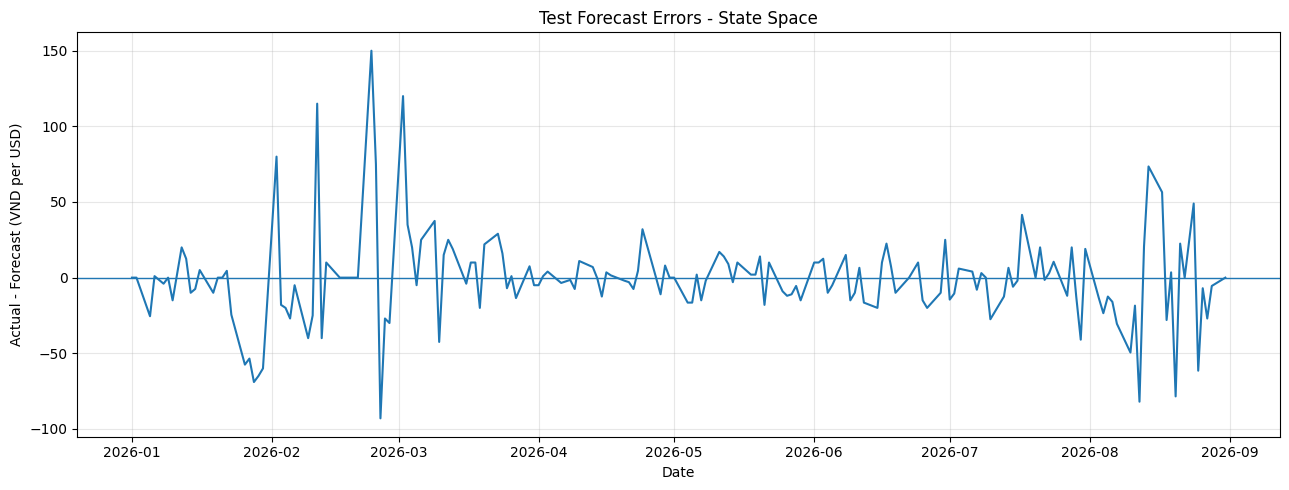

In [18]:
plt.figure(figsize=(13, 5))
plt.plot(test_predictions["Date"], test_predictions["Error"])
plt.axhline(0, linewidth=1)
plt.title("Test Forecast Errors - State Space")
plt.xlabel("Date")
plt.ylabel("Actual - Forecast (VND per USD)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "08_test_forecast_errors.png", dpi=300)
plt.show()

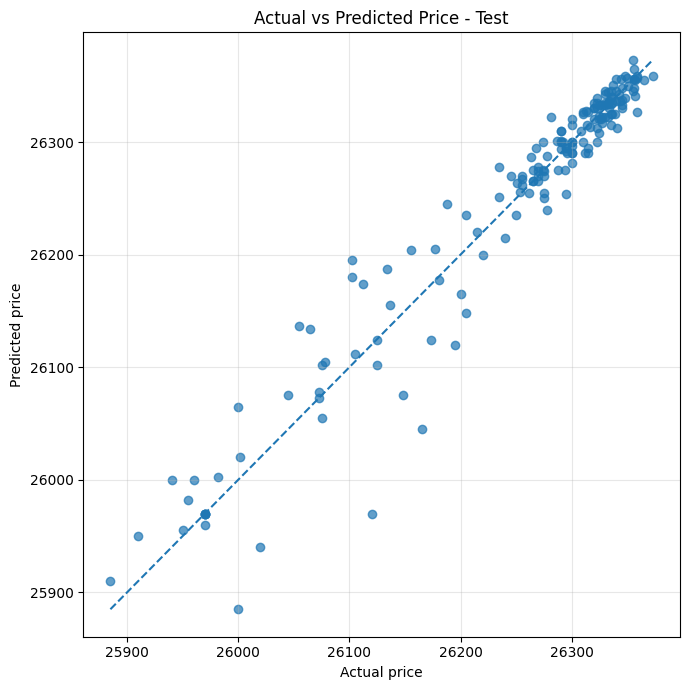

In [19]:
plt.figure(figsize=(7, 7))
plt.scatter(
    test_predictions["Actual_Close"],
    test_predictions["Predicted_Price"],
    alpha=0.7
)

min_v = min(test_predictions["Actual_Close"].min(), test_predictions["Predicted_Price"].min())
max_v = max(test_predictions["Actual_Close"].max(), test_predictions["Predicted_Price"].max())
plt.plot([min_v, max_v], [min_v, max_v], linestyle="--")

plt.title("Actual vs Predicted Price - Test")
plt.xlabel("Actual price")
plt.ylabel("Predicted price")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "09_actual_vs_predicted_scatter.png", dpi=300)
plt.show()

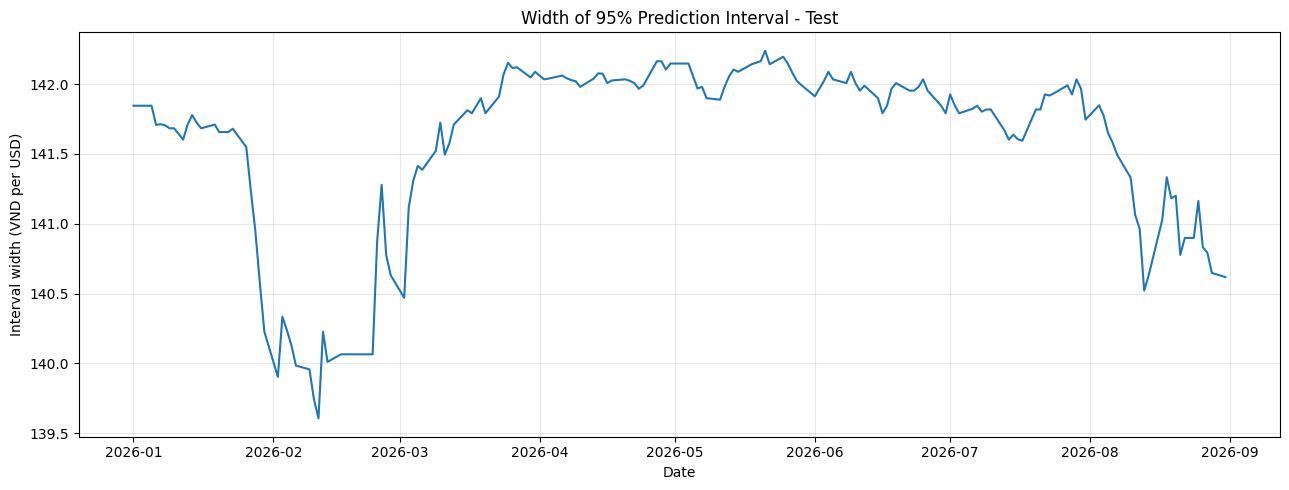

In [20]:
plt.figure(figsize=(13, 5))
interval_width = test_predictions["Upper_95"] - test_predictions["Lower_95"]
plt.plot(test_predictions["Date"], interval_width)
plt.title("Width of 95% Prediction Interval - Test")
plt.xlabel("Date")
plt.ylabel("Interval width (VND per USD)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "10_prediction_interval_width.png", dpi=300)
plt.show()

## 13. Fixed-origin multi-step forecast trên toàn bộ Test

Phần này **không phải tiêu chí đánh giá chính**. Nó minh họa điều gì xảy ra nếu đứng ở cuối 2025 và dự báo toàn bộ 2026 mà **không cập nhật bằng các quan sát 2026**.

So sánh với rolling one-step giúp thấy vai trò của Kalman updating và mức độ bất định tăng theo horizon.

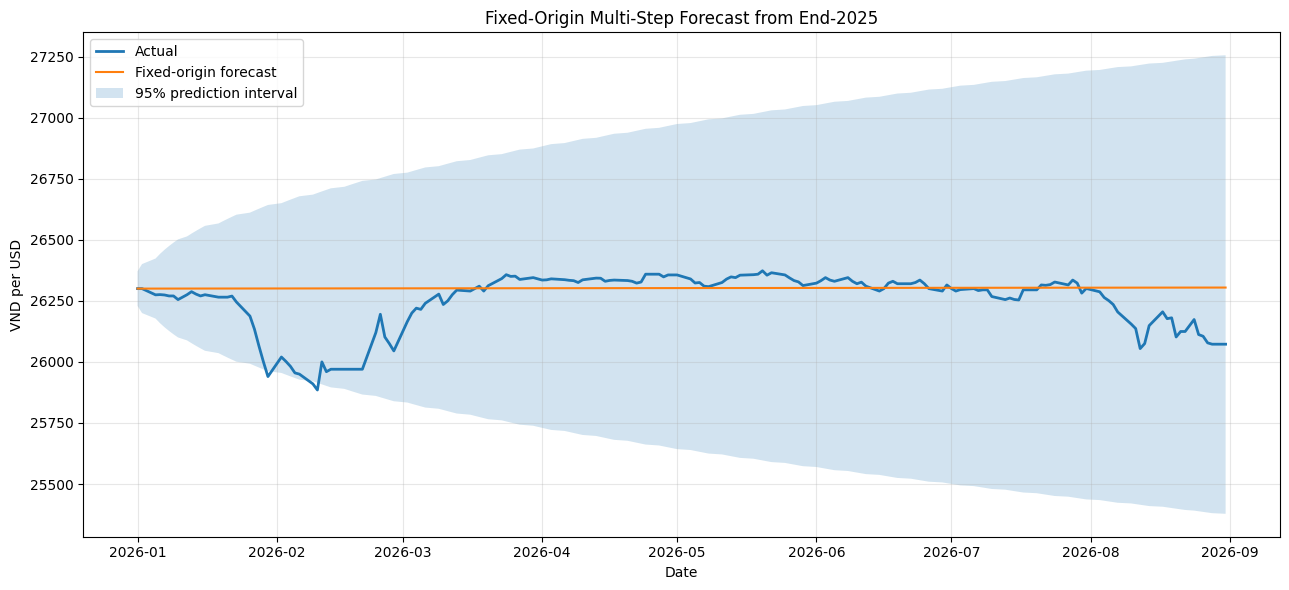

In [21]:
fixed_fc = final_result.get_forecast(steps=len(price_test))
fixed_mean_log = np.asarray(fixed_fc.predicted_mean, dtype=float)
fixed_var_log = np.maximum(np.asarray(fixed_fc.var_pred_mean, dtype=float), 0.0)
fixed_ci_log = np.asarray(fixed_fc.conf_int(alpha=0.05), dtype=float)

fixed_pred = np.exp(fixed_mean_log + 0.5 * fixed_var_log)
fixed_lower = np.exp(fixed_ci_log[:, 0])
fixed_upper = np.exp(fixed_ci_log[:, 1])

fixed_origin = pd.DataFrame({
    "Date": price_test["Date"].to_numpy(),
    "Actual_Close": price_test["Close"].to_numpy(),
    "Predicted_Price": fixed_pred,
    "Lower_95": fixed_lower,
    "Upper_95": fixed_upper,
})

fixed_origin.to_csv(
    RESULT_DIR / "08_fixed_origin_test_forecast.csv",
    index=False
)

plt.figure(figsize=(13, 6))
plt.plot(fixed_origin["Date"], fixed_origin["Actual_Close"], label="Actual", linewidth=2)
plt.plot(fixed_origin["Date"], fixed_origin["Predicted_Price"], label="Fixed-origin forecast")
plt.fill_between(
    fixed_origin["Date"],
    fixed_origin["Lower_95"],
    fixed_origin["Upper_95"],
    alpha=0.20,
    label="95% prediction interval"
)
plt.title("Fixed-Origin Multi-Step Forecast from End-2025")
plt.xlabel("Date")
plt.ylabel("VND per USD")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "11_fixed_origin_forecast.png", dpi=300)
plt.show()

## 14. Chẩn đoán innovation/residual của mô hình cuối

Trong State Space, đối tượng phù hợp để kiểm tra là **standardized one-step-ahead forecast errors (standardized innovations)**.

Tiêu chí:

- **Ljung-Box:** p-value > 0.05 là mong muốn, cho thấy chưa phát hiện autocorrelation còn sót.
- **Jarque-Bera:** p-value > 0.05 hỗ trợ giả định Gaussian; p-value nhỏ cho thấy đuôi dày/lệch chuẩn.
- **ARCH-LM:** p-value > 0.05 là mong muốn nếu mô hình đã giải thích tốt conditional heteroskedasticity. Nếu p-value nhỏ, State Space mean/trend model vẫn còn bỏ sót biến động phương sai, là một hạn chế quan trọng khi so với GARCH.

In [22]:
std_innov = np.asarray(
    final_result.filter_results.standardized_forecasts_error[0],
    dtype=float
)

burn = int(getattr(final_result, "loglikelihood_burn", 0))
std_innov[:burn] = np.nan

innovation_df = pd.DataFrame({
    "Date": price_train_val["Date"].to_numpy(),
    "Standardized_Innovation": std_innov
}).dropna().reset_index(drop=True)

z = innovation_df["Standardized_Innovation"].to_numpy()

ljung = acorr_ljungbox(
    z,
    lags=[5, 10, 20],
    return_df=True
).reset_index().rename(columns={"index": "Lag"})

jb = jarque_bera(z)
arch = het_arch(z, nlags=10)

residual_summary = pd.DataFrame({
    "Diagnostic": [
        "Mean standardized innovation",
        "Std standardized innovation",
        "Jarque-Bera statistic",
        "Jarque-Bera p-value",
        "ARCH-LM statistic (10 lags)",
        "ARCH-LM p-value (10 lags)",
        "ARCH F statistic",
        "ARCH F p-value",
    ],
    "Value": [
        np.mean(z),
        np.std(z, ddof=1),
        jb.statistic,
        jb.pvalue,
        arch[0],
        arch[1],
        arch[2],
        arch[3],
    ]
})

print("LJUNG-BOX STANDARDIZED INNOVATIONS")
print(ljung.to_string(index=False))
print("\nRESIDUAL DIAGNOSTICS")
print(residual_summary.to_string(index=False))

innovation_df.to_csv(RESULT_DIR / "09_standardized_innovations.csv", index=False)
ljung.to_csv(RESULT_DIR / "10_ljung_box_innovations.csv", index=False)
residual_summary.to_csv(RESULT_DIR / "11_residual_diagnostics.csv", index=False)

LJUNG-BOX STANDARDIZED INNOVATIONS
 Lag    lb_stat  lb_pvalue
   5 101.646406   0.000000
  10 130.220468   0.000000
  20 136.360236   0.000000

RESIDUAL DIAGNOSTICS
                  Diagnostic         Value
Mean standardized innovation      0.044433
 Std standardized innovation      1.002021
       Jarque-Bera statistic 29,195.781773
         Jarque-Bera p-value      0.000000
 ARCH-LM statistic (10 lags)    274.367910
   ARCH-LM p-value (10 lags)      0.000000
            ARCH F statistic     30.546565
              ARCH F p-value      0.000000


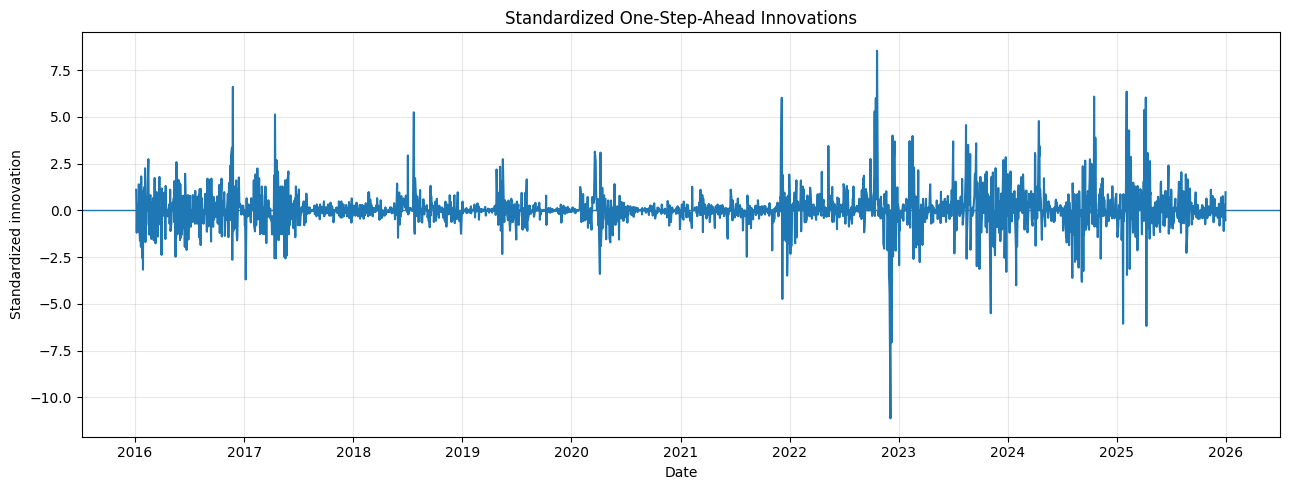

In [23]:
plt.figure(figsize=(13, 5))
plt.plot(innovation_df["Date"], innovation_df["Standardized_Innovation"])
plt.axhline(0, linewidth=1)
plt.title("Standardized One-Step-Ahead Innovations")
plt.xlabel("Date")
plt.ylabel("Standardized innovation")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "12_standardized_innovations.png", dpi=300)
plt.show()

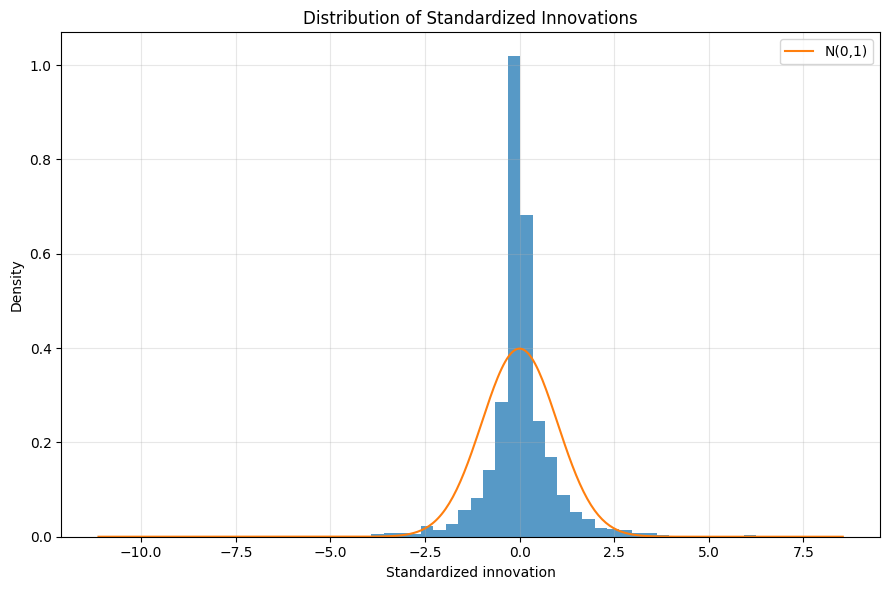

In [24]:
plt.figure(figsize=(9, 6))
plt.hist(z, bins=60, density=True, alpha=0.75)

x = np.linspace(z.min(), z.max(), 400)
plt.plot(x, norm.pdf(x, loc=0, scale=1), label="N(0,1)")

plt.title("Distribution of Standardized Innovations")
plt.xlabel("Standardized innovation")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "13_innovation_histogram.png", dpi=300)
plt.show()

<Figure size 1000x500 with 0 Axes>

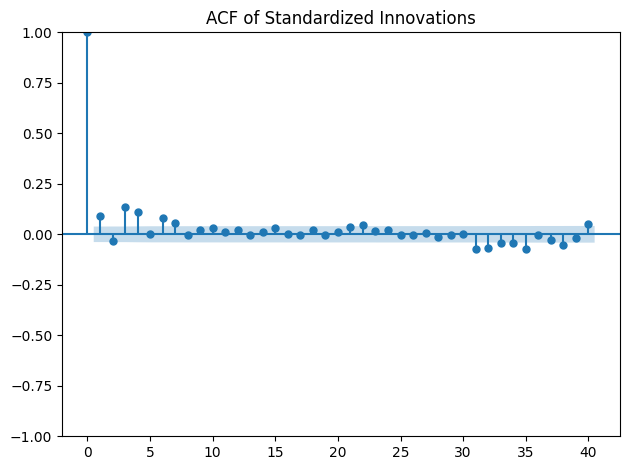

In [25]:
plt.figure(figsize=(10, 5))
plot_acf(z, lags=40)
plt.title("ACF of Standardized Innovations")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "14_acf_standardized_innovations.png", dpi=300)
plt.show()

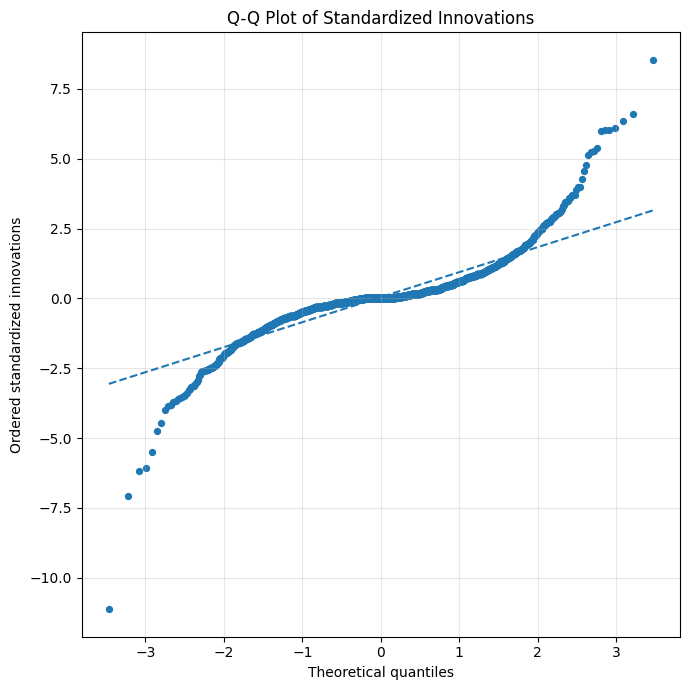

In [26]:
plt.figure(figsize=(7, 7))
(osm, osr), (slope, intercept, r_value) = probplot(z, dist="norm")
plt.scatter(osm, osr, s=18)
plt.plot(osm, slope * np.asarray(osm) + intercept, linestyle="--")
plt.title("Q-Q Plot of Standardized Innovations")
plt.xlabel("Theoretical quantiles")
plt.ylabel("Ordered standardized innovations")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "15_qq_standardized_innovations.png", dpi=300)
plt.show()

## 15. Kalman Smoother: trạng thái ẩn Level và Trend

Đây là phần đặc trưng của mô hình State Space. Ta không chỉ forecast mà còn tách ra:

- **Smoothed level**: mức log-price ẩn được làm trơn bằng toàn bộ Train + Validation.
- **Smoothed trend**: slope/trend ẩn nếu cấu trúc được chọn có thành phần trend.

Smoothed states dùng cho **giải thích mô hình**, không dùng làm dự báo ngoài mẫu.

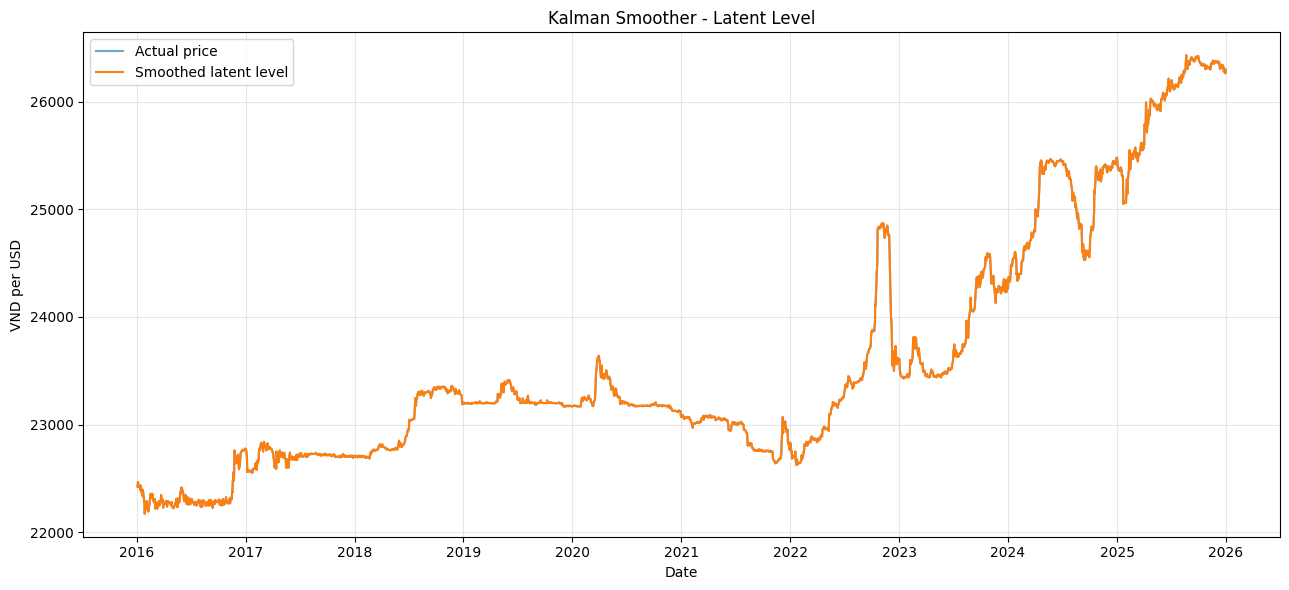

In [27]:
if hasattr(final_result, "level") and final_result.level is not None:
    smoothed_level = np.asarray(final_result.level.smoothed, dtype=float)

    state_level_df = pd.DataFrame({
        "Date": price_train_val["Date"].to_numpy(),
        "Actual_Close": price_train_val["Close"].to_numpy(),
        "Smoothed_Level_Log": smoothed_level,
        "Smoothed_Level_Price": np.exp(smoothed_level),
    })

    state_level_df.to_csv(
        RESULT_DIR / "12_smoothed_level.csv",
        index=False
    )

    plt.figure(figsize=(13, 6))
    plt.plot(state_level_df["Date"], state_level_df["Actual_Close"], label="Actual price", alpha=0.65)
    plt.plot(state_level_df["Date"], state_level_df["Smoothed_Level_Price"], label="Smoothed latent level", linewidth=1.5)
    plt.title("Kalman Smoother - Latent Level")
    plt.xlabel("Date")
    plt.ylabel("VND per USD")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "16_smoothed_level.png", dpi=300)
    plt.show()

In [28]:
trend_available = (
    hasattr(final_result, "trend")
    and final_result.trend is not None
    and hasattr(final_result.trend, "smoothed")
    and final_result.trend.smoothed is not None
)

if trend_available:
    smoothed_trend = np.asarray(final_result.trend.smoothed, dtype=float)

    trend_df = pd.DataFrame({
        "Date": price_train_val["Date"].to_numpy(),
        "Smoothed_Trend": smoothed_trend,
    })

    trend_df.to_csv(
        RESULT_DIR / "13_smoothed_trend.csv",
        index=False
    )

    plt.figure(figsize=(13, 5))
    plt.plot(trend_df["Date"], trend_df["Smoothed_Trend"])
    plt.axhline(0, linewidth=1)
    plt.title("Kalman Smoother - Latent Trend")
    plt.xlabel("Date")
    plt.ylabel("Trend in log-price per observation")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "17_smoothed_trend.png", dpi=300)
    plt.show()
else:
    print("Mô hình được chọn không có state trend riêng -> bỏ qua biểu đồ trend.")

Mô hình được chọn không có state trend riêng -> bỏ qua biểu đồ trend.


## 16. Bảng kết luận tự động cho mô hình số 3

Cell dưới tạo một bảng tóm tắt để đưa vào báo cáo. Không nên diễn giải kiểu "mô hình tốt" chỉ vì một chỉ tiêu. Cần đọc đồng thời:

- Forecast accuracy trên Test.
- So với Naive.
- Coverage của prediction interval.
- Residual/innovation diagnostics.
- Bối cảnh Test 2026 có thể chứa biến động mạnh hơn giai đoạn ước lượng.

In [29]:
ljung20_p = float(ljung.loc[ljung["Lag"] == 20, "lb_pvalue"].iloc[0]) if 20 in ljung["Lag"].values else np.nan
jb_p = float(jb.pvalue)
arch_p = float(arch[1])

final_conclusion = pd.DataFrame({
    "Criterion": [
        "Selected State Space specification",
        "Test MAE",
        "Test RMSE",
        "Test MAPE (%)",
        "Test sMAPE (%)",
        "Test MASE",
        "Directional Accuracy (%)",
        "Relative RMSE vs Naive",
        "95% PI Coverage (%)",
        "Average 95% PI Width",
        "Ljung-Box p-value lag 20",
        "Jarque-Bera p-value",
        "ARCH-LM p-value",
        "Optimizer converged",
    ],
    "Value": [
        best_model_name,
        test_metrics["MAE"],
        test_metrics["RMSE"],
        test_metrics["MAPE_percent"],
        test_metrics["sMAPE_percent"],
        test_metrics["MASE"],
        test_metrics["Directional_Accuracy_percent"],
        test_metrics["Relative_RMSE_vs_Naive"],
        test_metrics["PI95_Coverage_percent"],
        test_metrics["Average_PI95_Width"],
        ljung20_p,
        jb_p,
        arch_p,
        bool(final_result.mle_retvals.get("converged", True)),
    ]
})

print(final_conclusion.to_string(index=False))

final_conclusion.to_csv(
    RESULT_DIR / "14_final_conclusion_table.csv",
    index=False
)

                         Criterion       Value
Selected State Space specification Local Level
                          Test MAE   18.567821
                         Test RMSE   30.054512
                     Test MAPE (%)    0.070918
                    Test sMAPE (%)    0.070926
                         Test MASE    1.016560
          Directional Accuracy (%)   40.000000
            Relative RMSE vs Naive    1.000037
               95% PI Coverage (%)   94.857143
              Average 95% PI Width  141.569833
          Ljung-Box p-value lag 20    0.000000
               Jarque-Bera p-value    0.000000
                   ARCH-LM p-value    0.000000
               Optimizer converged        True


# Cách đọc kết quả khi viết báo cáo

### 1. Chọn cấu trúc
Nêu ba cấu trúc đã thử và chọn cấu trúc có **RMSE Validation thấp hơn**, không chọn theo Test.

### 2. Chất lượng point forecast
Báo cáo ít nhất **MAE, RMSE, MAPE, sMAPE**. Với toàn bộ 5 mô hình của nhóm, cần dùng cùng tập Test và cùng cách rolling one-step để so sánh công bằng.

### 3. So với Naive
- `MASE < 1`: State Space thắng Naive về MAE theo thang MASE.
- `Relative_RMSE_vs_Naive < 1`: State Space thắng Naive về RMSE.
- Nếu >= 1, ghi nhận mô hình chưa vượt benchmark.

### 4. Hướng tăng/giảm
`Directional Accuracy` chỉ phản ánh khả năng dự báo hướng, không thay thế MAE/RMSE.

### 5. Khoảng dự báo
Coverage 95% nên được xem cùng độ rộng. Coverage cao nhưng interval quá rộng không có nghĩa là forecast tốt.

### 6. Diagnostics
- Ljung-Box p > 0.05: chưa phát hiện serial correlation còn lại.
- Jarque-Bera p > 0.05: dữ liệu phù hợp hơn với Gaussian; nếu nhỏ, ghi nhận vi phạm normality.
- ARCH-LM p > 0.05: chưa phát hiện ARCH effect còn lại; nếu nhỏ, State Space hiện tại chưa mô hình hóa tốt volatility, đây là điểm GARCH có thể có lợi thế.

### 7. Vai trò của Kalman Filter / Smoother
- Filter phục vụ cập nhật trạng thái và forecast tuần tự.
- Smoother giúp giải thích latent level/trend trong quá khứ.

**Không được quay lại điều chỉnh cấu trúc dựa trên kết quả Test 2026.** Nếu Test xấu, đó vẫn là kết quả nghiên cứu hợp lệ.

## 17. Danh sách file được tạo

### Results
- `01_data_audit.csv`
- `02_candidate_validation_metrics.csv`
- `03_final_model_summary.txt`
- `04_final_model_parameters.csv`
- `05_test_metrics_state_space.csv`
- `06_test_predictions_state_space.csv`
- `07_state_space_vs_naive.csv`
- `08_fixed_origin_test_forecast.csv`
- `09_standardized_innovations.csv`
- `10_ljung_box_innovations.csv`
- `11_residual_diagnostics.csv`
- `12_smoothed_level.csv`
- `13_smoothed_trend.csv` nếu mô hình có trend
- `14_final_conclusion_table.csv`
- `state_space_final_model.pkl`

### Figures
Notebook lưu riêng toàn bộ biểu đồ vào `figures/model_3_state_space/` để đưa vào báo cáo và slide.